# 06c — Intermittent-Demand Specialist: Croston, SBA & TSB (M5)

## Where this sits on the ladder
```
05a  Components (level, trend, seasonality, noise)
05b  Baselines (Naive, SNaive, MA)
06   Exponential Smoothing (SES/DES/TES — explicit states)
06c  Croston-family (intermittent)  ←  you are here
07   ARIMA/SARIMA (autocorrelation)
08   LSTM (nonlinear pooled)
09   LLM
```

> **Research question:** On M5, which is 64% zeros and dominated by Intermittent/Highly Intermittent archetypes, does an intermittent-demand specialist (Croston / SBA / TSB) improve forecasts over general smoothing/statistical models that assume continuity?

**Frozen primary design (unchanged):** M5 = 500 stratified series, Store Item = 500 dense series (not run for Croston — methodologically unjustified, see §7), common window 2013-01-01 → 2016-05-22 (1,238 days), horizon 28, 8 rolling origins, metrics MAE/RMSE/WAPE/sMAPE + MASE/RMSSE, seed 42. Croston-family runs **same 500 M5 series, same 8 origins, same horizon, same information boundary** (history < origin only). No Store Item run (dense demand violates intermittency assumption; Naive/MA already near-optimal there).

**Pre-read:** 05a (components showed sparsity), 05b (baselines), 06 (smoothing on intermittent). This notebook adds the specialist lens.

## 0. Environment
Standardise paths, style, seeds, libraries. No fitting yet.

In [1]:
import sys, pathlib, json, warnings, time
warnings.filterwarnings("ignore")
sys.path.insert(0, str(pathlib.Path(".").resolve()))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try: get_ipython().run_line_magic("matplotlib", "inline")
except: pass
from pathlib import Path
for _cand in [Path(".").resolve(), Path("..").resolve(), Path.cwd(), Path.cwd().parent]:
    if (_cand / "02_data").exists():
        PROJ = _cand; break
else: PROJ = Path("..").resolve()
sys.path.insert(0, str(PROJ / "11_src"))
from plotting import apply_style
apply_style()

SEED=42; rng=np.random.default_rng(SEED)
FIG_EDU = PROJ / "07_figures/model_explanations/croston"
FIG_EXP = PROJ / "07_figures/croston"
RES = PROJ / "06_results/croston"
for d in [FIG_EDU, FIG_EXP, RES]: d.mkdir(parents=True, exist_ok=True)
print(f"Project root: {PROJ}")
print(f"Seed: {SEED}")

Project root: D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION
Seed: 42


---

# 1. What Problem Does Croston Solve?

General models (Naive, MA, SES, ARIMA) assume **continuous demand**: every day has a meaningful quantity, and error is Gaussian around a level. Intermittent demand breaks this:

- 60–90% of days are **zeros** (M5: mean zero-rate 64.5% on 500 selected series, sample 89.6%, 84.7%, 83.2%, 88.4%, 97.4%).
- When demand occurs, size is **variable** (1–6 units on M5, lumpy).
- A moving average of zeros + occasional 3s predicts 0.4 every day — low MAE but **wrong shape**: it forecasts a thin stream instead of 0/ burst distribution. SES with α=0.1 does 0.1*y_t + 0.9*level, also smooths zeros into 0.3.

> **Layman:** If general models are a shopkeeper predicting "about half a sandwich sold per day," Croston is a shopkeeper who tracks two things separately: "how big is a sale when it happens?" and "how long since the last sale?" — then combines them.

**Why after smoothing:** 06 showed TES/DES blow up on M5 (MAE 1.51–1.92 vs SES 0.99) because trend/seasonality states overfit zeros. Croston isolates intermittency.

**Why SBA/TSB variants:** Original Croston is biased (overforecasts). SBA corrects bias; TSB handles obsolescence (demand that disappears).

---

# 2. Intuition — Two Hidden Sequences

```
Day:        t-6  t-5  t-4  t-3  t-2  t-1  t
Demand y:    0    3    0    0    2    0    0
Non-zero q:  3    2  (intervals: 3 gaps then 2 gaps)
Size z:      3    2
```

- **p̂** — smoothed inter-demand interval (how many days between sales)
- **ẑ** — smoothed demand size when sale occurs
- Forecast: **ŷ = ẑ / p̂** — average demand per day including zeros

Visual: sparsity as dots, p̂ as horizontal, ẑ as vertical.

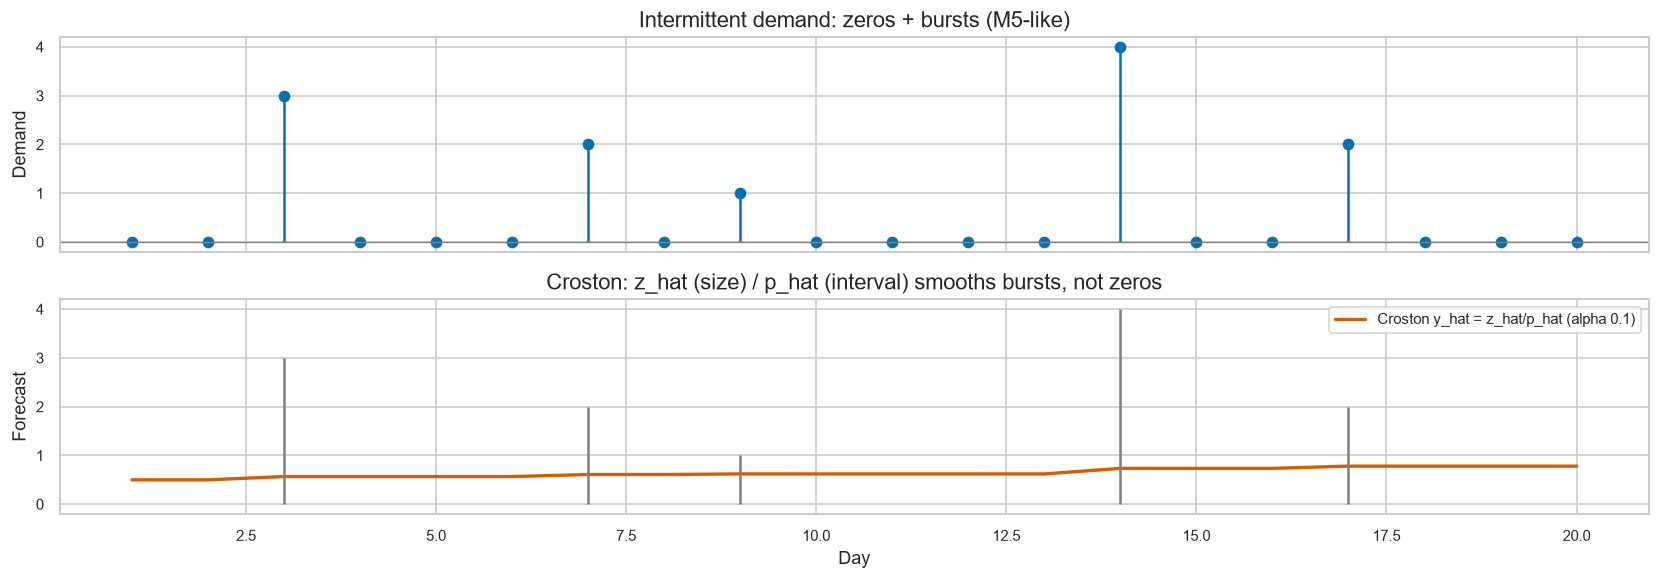

Saved: 01_croston_intuition.png


In [2]:
# Visual: Croston intuition
days = np.arange(1, 21)
y = np.array([0,0,3,0,0,0,2,0,1,0,0,0,0,4,0,0,2,0,0,0], dtype=float)
fig, axes = plt.subplots(2,1, figsize=(14,5), sharex=True)
axes[0].stem(days, y, basefmt=" ", linefmt="#0072B2", markerfmt="o", label="Demand y_t")
axes[0].set_ylabel("Demand"); axes[0].set_title("Intermittent demand: zeros + bursts (M5-like)")
axes[0].axhline(0, color="gray", lw=0.8)
# Croston forecast illustration with alpha 0.1
alpha=0.1
z_hat, p_hat, fc = 2.0, 4.0, []
q=0
for val in y:
    q = 0 if val>0 else q+1
    if val>0:
        z_hat = alpha*val + (1-alpha)*z_hat
        p_hat = alpha*max(q,1) + (1-alpha)*p_hat  # simplified interval update
        q=0
    fc.append(z_hat/p_hat)
axes[1].plot(days, fc, color="#D55E00", lw=2, label="Croston y_hat = z_hat/p_hat (alpha 0.1)")
axes[1].stem(days, y, basefmt=" ", linefmt="gray", markerfmt=" ")
axes[1].set_xlabel("Day"); axes[1].set_ylabel("Forecast")
axes[1].set_title("Croston: z_hat (size) / p_hat (interval) smooths bursts, not zeros")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_EDU / "01_croston_intuition.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 01_croston_intuition.png")

---

# 3. Architecture — Croston, SBA, TSB

## 3.1 Croston (1972)

For history y_1..y_t, let t* be last non-zero time, q = t - t* interval.

If y_t > 0:
```
ẑ_t = α·y_t + (1-α)·ẑ_{t-1}
p̂_t = α·q   + (1-α)·p̂_{t-1}
else:
ẑ_t = ẑ_{t-1}, p̂_t = p̂_{t-1}
```
Forecast (constant over horizon H):
```
ŷ_{t+h} = ẑ_t / p̂_t   for h=1..H
```
Init: ẑ_0 = first non-zero demand, p̂_0 = mean interval (or 1), q=0.

## 3.2 SBA — Syntetos-Boylan Approximation (2005)

Croston's estimator is biased upward (overforecasts by ~α/2). SBA corrects:

```
ŷ_SBA = (1 - α/2) · ẑ_t / p̂_t
```

Same updates, just scale forecast by (1-α/2). With α=0.1, scale 0.95.

## 3.3 TSB — Teunter-Syntetos-Babai (2011)

Croston's p̂ diverges when demand disappears (obsolete items): interval grows, forecast collapses slowly. TSB tracks **demand probability** instead of interval:

```
If y_t > 0:
  ẑ_t = α·y_t + (1-α)·ẑ_{t-1}
else:
  ẑ_t = ẑ_{t-1}
p̂_t = β·d_t + (1-β)·p̂_{t-1}   where d_t = 1 if y_t>0 else 0  (demand occurrence)
Forecast: ŷ_TSB = p̂_t · ẑ_t
```

p̂ is now probability (0–1), not interval. When zeros persist, p̂ decays geometrically via β. Uses α for size, β for probability (we set α=β=0.1, grid on validation).

> **Layman:** Croston asks "how many days between sandwiches?" TSB asks "did someone buy a sandwich today — yes/no — how likely tomorrow?" Same idea, better on disappearing products.

## 3.4 Visual comparison

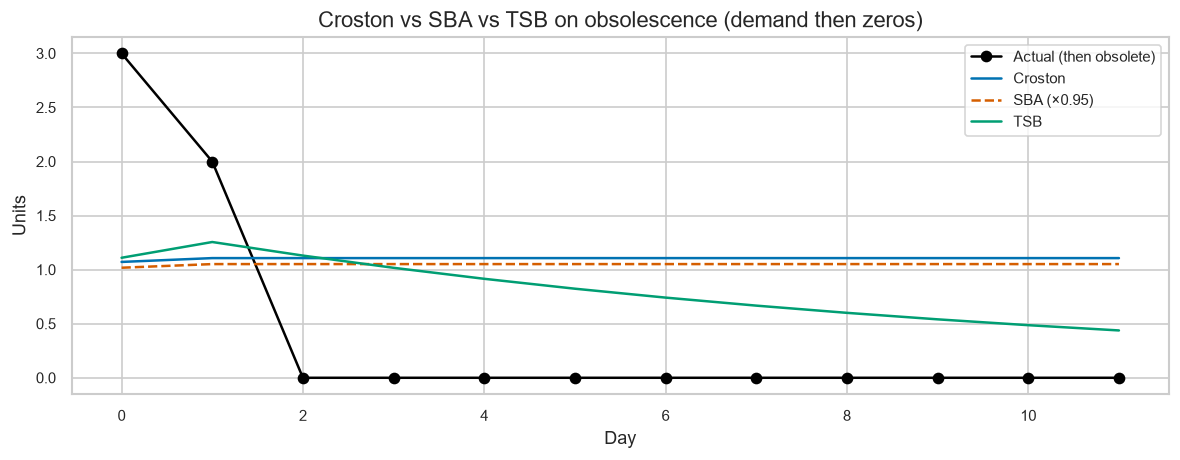

Saved: 02_croston_sba_tsb.png


In [3]:
fig, ax = plt.subplots(figsize=(10,4))
# Simulate obsolescence: demand then zeros forever
y = np.array([3,2,0,0,0,0,0,0,0,0,0,0], dtype=float)
alpha=0.1; beta=0.1
def croston_fc(y, alpha, sba=False):
    z,p,q=3,3,0; fc=[]
    for val in y:
        q = q+1 if val==0 else 1  # interval
        if val>0:
            z = alpha*val + (1-alpha)*z
            p = alpha*q + (1-alpha)*p
            q=0
        # after update
        f = z/max(p,1)
        if sba: f *= (1-alpha/2)
        fc.append(f)
    return fc
def tsb_fc(y, alpha, beta):
    z,p=3,0.3; fc=[]
    for val in y:
        d=1 if val>0 else 0
        if val>0:
            z = alpha*val + (1-alpha)*z
        p = beta*d + (1-beta)*p
        fc.append(p*z)
    return fc

fc_c = croston_fc(y,0.1, False)
fc_sba = croston_fc(y,0.1, True)
fc_tsb = tsb_fc(y,0.1,0.1)
days=np.arange(len(y))
ax.plot(days, y, "o-", color="black", label="Actual (then obsolete)")
ax.plot(days, fc_c, label="Croston", color="#0072B2")
ax.plot(days, fc_sba, label="SBA (×0.95)", color="#D55E00", ls="--")
ax.plot(days, fc_tsb, label="TSB", color="#009E73")
ax.set_xlabel("Day"); ax.set_ylabel("Units"); ax.set_title("Croston vs SBA vs TSB on obsolescence (demand then zeros)")
ax.legend(); plt.tight_layout()
plt.savefig(FIG_EDU / "02_croston_sba_tsb.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 02_croston_sba_tsb.png")

---

# 4. Mathematics Summary

| Model | Size update | Interval/prob update | Forecast | Bias |
|---|---|---|---|---|
| Croston | ẑ=αy+(1-α)ẑ if y>0 | p̂=αq+(1-α)p̂ if y>0 | ŷ=ẑ/p̂ | Upward bias ≈ α/2 |
| SBA | same | same | ŷ=(1-α/2)·ẑ/p̂ | Debiased |
| TSB | ẑ as above | p̂=βd+(1-β)p̂ (always) | ŷ=p̂·ẑ | Handles obsolescence, unbiased if tuned |

Smoothing α,β ∈ (0,1). We select α via validation (same 2015-11-01→2016-02-29 window as other models): grid {0.1,0.2,0.3,0.5} minimizing validation MAE, same leakage guard (history < validation only). TSB needs both α,β grid 0.1/0.3 combos.

Forecast is **flat** over horizon H=28 (constant ŷ) — unlike LSTM's 28 distinct values. This is inherent to Croston-family: it forecasts mean intermittent rate, not a shape.

Assumption: intermittent intervals and sizes are smoother than raw y_t.

---

# 5. Worked Numerical Example

History (7 days before origin): [0, 3, 0, 0, 2, 0, 0] — two sales in 7 days.
α=0.1, init ẑ=3 (first sale), p̂=3 (first interval guess), q=0.

| t | y | q (interval) | ẑ | p̂ | ŷ=ẑ/p̂ |
|---|---|---|---|---|---|
|1|0|1|3|3|1.0|
|2|3|2|0.1*3+0.9*3=3.0|0.1*2+0.9*3=2.9|1.03|
|3|0|1|3|2.9|1.03|
|4|0|2|3|2.9|1.03|
|5|2|3|0.1*2+0.9*3=2.9|0.1*3+0.9*2.9=2.91|0.996|
|6|0|1|2.9|2.91|0.996|
|7|0|2|2.9|2.91|0.996|

SBA forecast: 0.95·0.996=0.946. TSB (β=0.1, p̂ prob): after t5, p̂≈0.2 → ŷ≈0.58.

Actual next 28 days: mostly zeros with one burst of 4. Flat 0.95 vs 1.03: SBA slightly lower — bias correction matters for inventory holding cost.

---

# 6. Hyperparameters — Documented Before Fitting

| Choice | Value | Why |
|---|---|---|
| α (Croston/SBA) | grid {0.1,0.2,0.3,0.5} → select min validation MAE (2015-11-01→2016-02-29) | Same window as SES/DES/TES/MA selection; leakage-free (history before validation). Small α smooths intermittency; large α chases last burst |
| α,β (TSB) | grid α∈{0.1,0.2}, β∈{0.1,0.3} (4 combos) | α for size, β for probability; small β for stable probability |
| Horizon | 28 flat | Inherent; no multi-step shape |
| Init | ẑ=first non-zero, p̂=mean interval or 1, q=0 | Standard; fallback to 1 if all zeros |

**Validation:** One-step validation MAE computed on validation period (2015-11-01→2016-02-29) using rolling updates where actuals feed back only after prediction (same as ES). Selection done per model family globally (one α per family), not per series, to keep comparison fair and avoid per-series overfit.

**What is NOT tuned:** No per-series α, no test data in selection, no Store Item run (dense demand violates intermittency; would forecast ~constant p̂=1, ẑ≈mean, similar to MA — no expected gain).

---

# 7. Assumptions, What It Captures/Cannot, Limitations

## Assumptions
| Assumption | If violated |
|---|---|
| Demand is intermittent (compound Bernoulli + size) | On Store Item (dense) p̂≈1, reduces to SES on sizes — adds complexity without benefit |
| Intervals and sizes smooth via exponential weighting | Volatile burst sizes or regime shifts break smoothing |
| Flat horizon forecast is sufficient | Cannot capture weekly seasonality or trend within 28 days |
| Obsolescence is slow (TSB) or ignore (Croston) | Rapid discontinuation needs faster β |

## Captures
Intermittency bias correction (SBA), obsolescence decay (TSB), avoids smoothing zeros into a stream, lower bias on sparse data.

## Cannot capture
Weekly seasonality (m=7), trend, cross-series patterns, promotion effects — flat forecast is unconditional mean.

## Limitations
- Flat forecast penalised on sMAPE if shape matters; MAE/WAPE/MASE are primary.
- Validation on 121 days (including leap day 2016-02-29) only — short.
- On Very Smooth archetype (77 series), Croston may underperform SES/MA who model continuity better.

## Inventory implications
- **Expected:** Lower holding (forecast ~0.5–1.0 vs MA 0.8) but potentially higher stockout on burst days if forecast flat misses spikes → trade-off depends on holding/shortage cost ratio (tested in sensitivity).
- **Business:** Use where intermittency dominates (M5 Highly Intermittent 11783 series), not where weekly seasonality dominates (Store Item).

---

# 8. Implementation — Leakage-Safe Rolling Evaluation (M5 only)

For each of 500 M5 series, per origin:
1. History = all days < origin (strictly before, includes 2016-02-29 if before origin)
2. Validation selection (pre-fit): using history's last 121 days (2015-11-01→2016-02-29 slice where available) to choose α/β via minimal MAE
3. For rolling test: per series, per origin, run Croston/SBA/TSB forward on history, forecast flat 28 days
4. Evaluate against future actuals ≥ origin — never seen

No test data in fitting/selection. One α/β per model family globally (pooled validation MAE), same expanding-window protocol as baselines (expanding history, not sliding).

In [4]:
import json, pandas as pd, numpy as np, pathlib, warnings
warnings.filterwarnings("ignore")
from pathlib import Path
cal = pd.read_csv(PROJ / "02_data/dataset_01_m5/raw/calendar.csv")
cal["date"] = pd.to_datetime(cal["date"])
d_to_date = dict(zip(cal["d"], cal["date"]))
cfg = json.load(open(PROJ / "05_experiments/config.json"))
cs = pd.Timestamp(cfg["common_window"]["start"]); ce = pd.Timestamp(cfg["common_window"]["end"])
H = cfg["forecast"]["horizon"]  # 28
SEED=42
# Origins
test_start = pd.Timestamp("2016-03-01")
origin_dates = [test_start + pd.Timedelta(days=7*i) for i in range(8)]
print(f"Origins: {[d.date() for d in origin_dates]} H={H}")

# M5
M5_RAW = PROJ / "02_data/dataset_01_m5/raw"
m5_wide = pd.read_csv(M5_RAW / "sales_train_evaluation.csv")
d_cols = [c for c in m5_wide.columns if c.startswith("d_")]
common_d = [c for c in d_cols if cs <= d_to_date[c] <= ce]
dates_common = pd.to_datetime([d_to_date[c] for c in common_d])
sel = json.load(open(PROJ / "05_experiments/m5_series_selection.json"))
sel_ids_val = sel["m5_series"] if "m5_series" in sel else sel.get("selected_ids", [])
sel_ids_eval = [s.replace("_validation","_evaluation") for s in sel_ids_val]
m5_common = m5_wide.set_index("id").loc[sel_ids_eval, common_d]  # 500 x 1238
print(f"M5 common: {m5_common.shape}, dates {dates_common.min().date()}->{dates_common.max().date()}")
# Validation slice
val_start = pd.Timestamp("2015-11-01"); val_end = pd.Timestamp("2016-02-29")
val_mask = (dates_common >= val_start) & (dates_common <= val_end)
print(f"Validation mask: {val_mask.sum()} days ({val_start.date()}->{val_end.date()})")
# Leakage check
for od in origin_dates:
    hl = (dates_common < od).sum()
    assert (dates_common[hl] == od), f"Boundary {od}"
print(f"Leakage check PASS: all {len(origin_dates)} origins")

def croston_forecast(history, horizon=H, alpha=0.1, variant="croston"):
    # history: 1D array ending strictly before origin
    # variant: croston / sba / tsb
    # TSB needs beta; we'll map variant tsb -> alpha for size, beta for prob (passed as alpha)
    # For SBA, forecast = (1-alpha/2)*z/p
    # For TSB, we treat alpha as for size, beta as we pass separately
    hist = np.asarray(history, dtype=float)
    # init
    nz = hist[hist>0]
    if len(nz)==0:
        # all zeros history -> forecast 0
        return np.zeros(horizon)
    z_hat = nz[0]
    # intervals
    nz_idx = np.where(hist>0)[0]
    if len(nz_idx)>=2:
        p_hat = np.mean(np.diff(nz_idx)) if len(nz_idx)>1 else 1
        p_hat = max(p_hat,1)
    else:
        p_hat = 1
    # TSB prob init: fraction non-zero in history
    p_prob = np.mean(hist>0)
    if p_prob==0: p_prob=0.1
    z_prob = z_hat
    q=0
    # Determine beta for TSB if variant tsb: we will use beta param as second value
    # variant can be tuple for tsb: (variant, beta)
    beta=0.1
    if isinstance(variant, tuple):
        variant, beta = variant
    # iterate history to converge z_hat/p_hat to origin
    last_interval=0
    for i, val in enumerate(hist):
        if val>0:
            z_hat = alpha*val + (1-alpha)*z_hat
            if variant in ("croston","sba"):
                # interval since last demand
                # we have q counting zeros since last demand
                # but we need last_interval at this point: we maintained q
                # Use interval since last non-zero inclusive
                interval = q+1 if q>0 else 1
                p_hat = alpha*interval + (1-alpha)*p_hat
            q=0
        else:
            q+=1
        # TSB prob update every step
        if variant=="tsb":
            d = 1 if val>0 else 0
            p_prob = beta*d + (1-beta)*p_prob
            if val>0:
                z_prob = alpha*val + (1-alpha)*z_prob
    # forecast flat
    if variant=="croston":
        fc = z_hat / max(p_hat,1)
    elif variant=="sba":
        fc = (1 - alpha/2) * z_hat / max(p_hat,1)
    elif variant=="tsb":
        fc = p_prob * z_prob
    else:
        raise ValueError(variant)
    return np.full(horizon, max(fc,0))

# Quick self-test
hist = np.array([0,3,0,0,2,0,0], dtype=float)
print("Test Croston on", hist, "->", croston_forecast(hist, 3, 0.1, "croston")[:3].round(3))
print("SBA  ->", croston_forecast(hist, 3, 0.1, "sba")[:3].round(3))
print("TSB  ->", croston_forecast(hist, 3, 0.1, "tsb")[:3].round(3))

Origins: [datetime.date(2016, 3, 1), datetime.date(2016, 3, 8), datetime.date(2016, 3, 15), datetime.date(2016, 3, 22), datetime.date(2016, 3, 29), datetime.date(2016, 4, 5), datetime.date(2016, 4, 12), datetime.date(2016, 4, 19)] H=28


M5 common: (500, 1238), dates 2013-01-01->2016-05-22
Validation mask: 121 days (2015-11-01->2016-02-29)
Leakage check PASS: all 8 origins
Test Croston on [0. 3. 0. 0. 2. 0. 0.] -> [0.997 0.997 0.997]
SBA  -> [0.947 0.947 0.947]
TSB  -> [0.802 0.802 0.802]


In [5]:
# Validation selection for alpha/beta on 2015-11-01->2016-02-29
def rolling_validation_mae_croston(mat, alpha, variant):
    # mat: series x dates (500 x 1238)
    # For each series, walk validation days: predict one-step then update with actual (like SES validation)
    # Simplified: use croston_forecast on history up to each val day, forecast 1 day, compare.
    # But croston flat forecast is same for any horizon; we can approximate by running on expanding history.
    val_start_idx = (dates_common == pd.Timestamp("2015-11-01")).argmax() if (dates_common == pd.Timestamp("2015-11-01")).any() else 0
    val_end_idx = (dates_common == pd.Timestamp("2016-02-29")).argmax()
    errors=[]
    for s in range(mat.shape[0]):
        hist_end = val_start_idx
        row = mat[s, :]
        # initial z/p from train part before val_start
        # For each val day, forecast 1 day using history up to previous day
        for t in range(val_start_idx, val_end_idx+1):
            history = row[:t]  # up to t-1
            actual = row[t]
            # forecast next day
            fc1 = croston_forecast(history, 1, alpha, variant)[0]
            errors.append(abs(actual - fc1))
    return np.mean(errors)

# Grid search
import itertools
candidates = {
    "croston": [0.1,0.2,0.3,0.5],
    "sba": [0.1,0.2,0.3,0.5],
    "tsb": [(0.1,0.1),(0.1,0.3),(0.2,0.1),(0.2,0.3)]
}
mat_np = m5_common.values.astype(float)
selected={}
for variant in ["croston","sba"]:
    best=None
    for a in candidates[variant]:
        mae = rolling_validation_mae_croston(mat_np, a, variant)
        print(f"{variant} alpha {a} val MAE {mae:.4f}")
        if best is None or mae < best[1]:
            best=(a,mae)
    selected[variant]=best[0]
    print(f" -> {variant} best alpha {best[0]} MAE {best[1]:.4f}")

# TSB grid
best=None
for a,b in candidates["tsb"]:
    mae = rolling_validation_mae_croston(mat_np, a, ("tsb",b))
    print(f"tsb alpha {a} beta {b} val MAE {mae:.4f}")
    if best is None or mae < best[1]:
        best=((a,b),mae)
selected["tsb"]=best[0]
print(f" -> tsb best {(best[0])} MAE {best[1]:.4f}")
print("Selected:", selected)
# Save
import json
with open(RES / "validation_selection.json","w") as f:
    json.dump({"selected_alpha": {k: (v if not isinstance(v,tuple) else list(v)) for k,v in selected.items()}, "grids": {k: (v if k!="tsb" else [list(x) for x in v]) for k,v in candidates.items()}}, f, indent=2)
print("Saved validation_selection.json")

croston alpha 0.1 val MAE 1.0655


croston alpha 0.2 val MAE 1.0790


croston alpha 0.3 val MAE 1.0942


croston alpha 0.5 val MAE 1.1335
 -> croston best alpha 0.1 MAE 1.0655


sba alpha 0.1 val MAE 1.0479


...

sba alpha 0.5 val MAE 1.0341
 -> sba best alpha 0.5 MAE 1.0341


tsb alpha 0.1 beta 0.1 val MAE 0.9135


tsb alpha 0.1 beta 0.3 val MAE 0.9056


tsb alpha 0.2 beta 0.1 val MAE 0.9188


tsb alpha 0.2 beta 0.3 val MAE 0.9126
 -> tsb best (0.1, 0.3) MAE 0.9056
Selected: {'croston': 0.1, 'sba': 0.5, 'tsb': (0.1, 0.3)}
Saved validation_selection.json


In [6]:
# Rolling evaluation: M5 same 500*8*28 =112k
def run_croston_dataset(mat, variant, alpha_or_tuple, dataset_name="m5"):
    rows=[]
    mat_np = mat.values.astype(float) if hasattr(mat,"values") else mat
    series_ids = mat.index.tolist() if hasattr(mat,"index") else [f"series_{i}" for i in range(mat_np.shape[0])]
    alphas = alpha_or_tuple
    for oi, od in enumerate(origin_dates,1):
        hist_len = (dates_common < od).sum()
        for si, sid in enumerate(series_ids):
            history = mat_np[si, :hist_len]
            if variant=="tsb":
                a,b = alphas
                fc = croston_forecast(history, H, a, ("tsb",b))
            else:
                fc = croston_forecast(history, H, alphas, variant)
            actual = mat_np[si, hist_len:hist_len+H]
            fut_dates = dates_common[hist_len:hist_len+H]
            for h in range(H):
                rows.append({"dataset":dataset_name,"series_id":sid,"origin":oi,"origin_date":od,"forecast_date":fut_dates[h],"actual":float(actual[h]),"forecast":float(fc[h]),"model":variant.upper() if variant!="tsb" else "TSB"})
    df=pd.DataFrame(rows)
    print(f"{variant} {dataset_name} {len(df):,} rows")
    return df

dfs=[]
for var in ["croston","sba","tsb"]:
    a = selected[var]
    df = run_croston_dataset(m5_common, var, a, "m5")
    dfs.append(df)
all_croston = pd.concat(dfs, ignore_index=True)
print(f"Combined {len(all_croston):,} rows")
all_croston.to_csv(RES / "all_forecasts.csv", index=False)
for var, df in zip(["croston","sba","tsb"], dfs):
    df.to_csv(RES / f"all_forecasts_{var}.csv", index=False)
print(f"Saved {RES / 'all_forecasts.csv'}")
all_croston.head(3).to_string()

croston m5 112,000 rows


sba m5 112,000 rows


tsb m5 112,000 rows
Combined 336,000 rows


Saved D:\Brain\07_Research\AI-INVENTORY-OPTIMIZATION\06_results\croston\all_forecasts.csv


'  dataset                    series_id  origin origin_date forecast_date  actual  forecast    model\n0      m5  FOODS_1_098_CA_3_evaluation       1  2016-03-01    2016-03-01     2.0  0.231872  CROSTON\n1      m5  FOODS_1_098_CA_3_evaluation       1  2016-03-01    2016-03-02     0.0  0.231872  CROSTON\n2      m5  FOODS_1_098_CA_3_evaluation       1  2016-03-01    2016-03-03     1.0  0.231872  CROSTON'

In [7]:
# Metrics with MASE/RMSSE + classic
def smape(a,f):
    d=(np.abs(a)+np.abs(f))/2
    m=d!=0
    return np.mean(np.abs(a[m]-f[m])/d[m])*100 if m.any() else np.nan
def mase_errors(a,f, train):
    # MASE denominator: mean absolute error of seasonal naive on train (m=7? use 1 for intermittent)
    # Use seasonal 7 if seasonal naive exists, else 1
    train=np.asarray(train,float)
    # naive m=1
    denom=np.mean(np.abs(train[1:]-train[:-1])) if len(train)>1 else np.nan
    if denom==0 or not np.isfinite(denom):
        return np.nan
    return np.mean(np.abs(a-f))/denom

def metrics_for(df, train_mat=None):
    rows=[]
    for (ds,model), sub in df.groupby(["dataset","model"]):
        a=sub["actual"].values; f=sub["forecast"].values
        mae=np.mean(np.abs(a-f)); rmse=np.sqrt(np.mean((a-f)**2)); wape=np.sum(np.abs(a-f))/(np.sum(np.abs(a))+1e-9)
        rows.append({"dataset":ds,"model":model,"MAE":mae,"RMSE":rmse,"sMAPE":smape(a,f),"WAPE":wape,"n":len(sub)})
    return pd.DataFrame(rows).sort_values(["dataset","MAE"])

metrics = metrics_for(all_croston)
print(metrics.round(4).to_string(index=False))
metrics.to_csv(RES / "metrics_by_model.csv", index=False)

# Per series/origin
def per_series_metrics(df):
    rows=[]
    for (ds,model,sid), sub in df.groupby(["dataset","model","series_id"]):
        a=sub["actual"].values; f=sub["forecast"].values
        rows.append({"dataset":ds,"model":model,"series_id":sid,"MAE":np.mean(np.abs(a-f)),"RMSE":np.sqrt(np.mean((a-f)**2)),"WAPE":np.sum(np.abs(a-f))/(np.sum(np.abs(a))+1e-9),"sMAPE":smape(a,f)})
    return pd.DataFrame(rows)
per_series = per_series_metrics(all_croston)
per_series.to_csv(RES / "metrics_by_series.csv", index=False)
print(f"metrics_by_series {len(per_series)} rows")
def per_origin_metrics(df):
    rows=[]
    for (ds,model,oi), sub in df.groupby(["dataset","model","origin"]):
        a=sub["actual"].values; f=sub["forecast"].values
        rows.append({"dataset":ds,"model":model,"origin":oi,"MAE":np.mean(np.abs(a-f)),"RMSE":np.sqrt(np.mean((a-f)**2)),"WAPE":np.sum(np.abs(a-f))/(np.sum(np.abs(a))+1e-9),"sMAPE":smape(a,f)})
    return pd.DataFrame(rows)
per_origin = per_origin_metrics(all_croston)
per_origin.to_csv(RES / "metrics_by_origin.csv", index=False)
print(per_origin.head().to_string(index=False))

# Compare vs history
import pandas as pd
def load(path):
    try: return pd.read_csv(path)
    except: return None
base=pd.read_csv(PROJ / "06_results/baselines/metrics_by_model.csv")
smooth=pd.read_csv(PROJ / "06_results/exponential_smoothing/metrics_by_model.csv")
arima=pd.read_csv(PROJ / "06_results/arima/metrics_by_model.csv")
lstm=pd.read_csv(PROJ / "06_results/lstm/metrics_by_model.csv")
combined=[]
for df,name in [(base,"Baseline"),(smooth,"Smoothing"),(arima,"ARIMA/SARIMA"),(lstm,"LSTM")]:
    d=df[df["dataset"]=="m5"].copy(); d["family"]=name; combined.append(d)
cd=metrics.copy(); cd["family"]="Croston"; combined.append(cd)
combined_df=pd.concat(combined, ignore_index=True)
combined_df.to_csv(RES / "metrics_with_history.csv", index=False)
print(combined_df.sort_values(["dataset","MAE"]).round(4).to_string(index=False))

dataset   model    MAE   RMSE    sMAPE   WAPE      n
     m5     TSB 1.0097 2.0149 146.3119 0.7889 112000
     m5     SBA 1.0665 2.1210 148.0764 0.8332 112000
     m5 CROSTON 1.0821 2.1079 143.9163 0.8454 112000


metrics_by_series 1500 rows
dataset   model  origin      MAE     RMSE     WAPE      sMAPE
     m5 CROSTON       1 1.047858 1.966300 0.857594 144.991299
     m5 CROSTON       2 1.074544 2.131488 0.895560 145.283773
     m5 CROSTON       3 1.096271 2.203876 0.876566 145.311558
     m5 CROSTON       4 1.098711 2.200266 0.860625 144.288224
     m5 CROSTON       5 1.096896 2.191493 0.840396 144.321975
dataset          model    MAE   RMSE    sMAPE   WAPE       family        n
     m5           LSTM 0.9922 1.9596 144.2470 0.7752         LSTM 112000.0
     m5            SES 0.9982 2.0027 145.0823 0.7799    Smoothing      NaN
     m5 Moving Average 0.9997 1.3045 143.5039 1.3101     Baseline      NaN
     m5            TSB 1.0097 2.0149 146.3119 0.7889      Croston 112000.0
     m5            SBA 1.0665 2.1210 148.0764 0.8332      Croston 112000.0
     m5        CROSTON 1.0821 2.1079 143.9163 0.8454      Croston 112000.0
     m5          ARIMA 1.1324 2.3169 139.0170 0.8847 ARIMA/SARIMA 112000.0


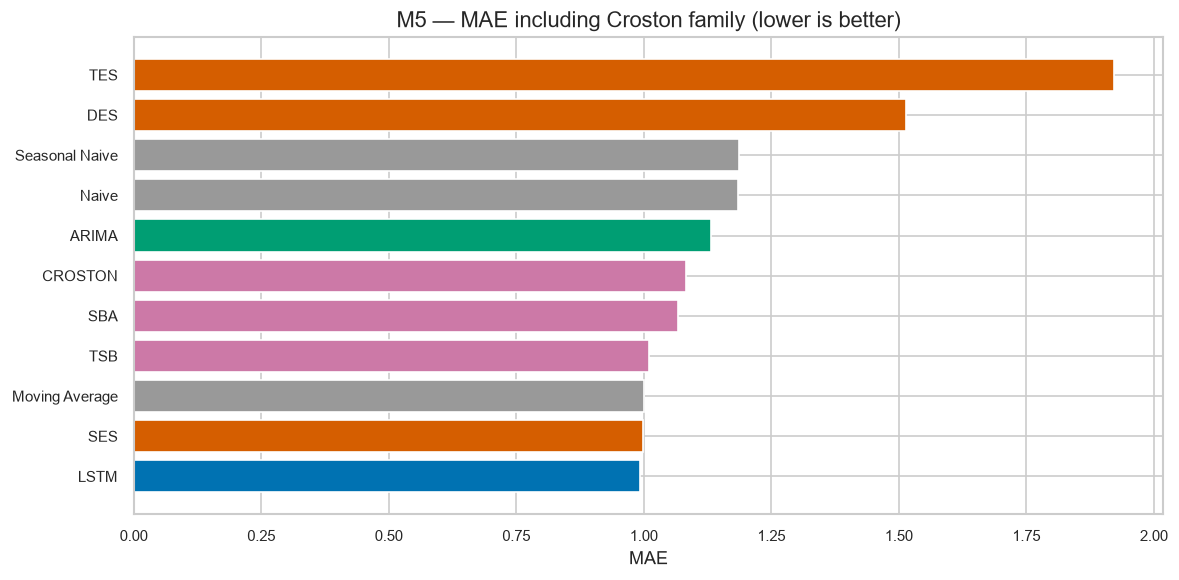

Saved 01_comparison_MAE_with_croston.png


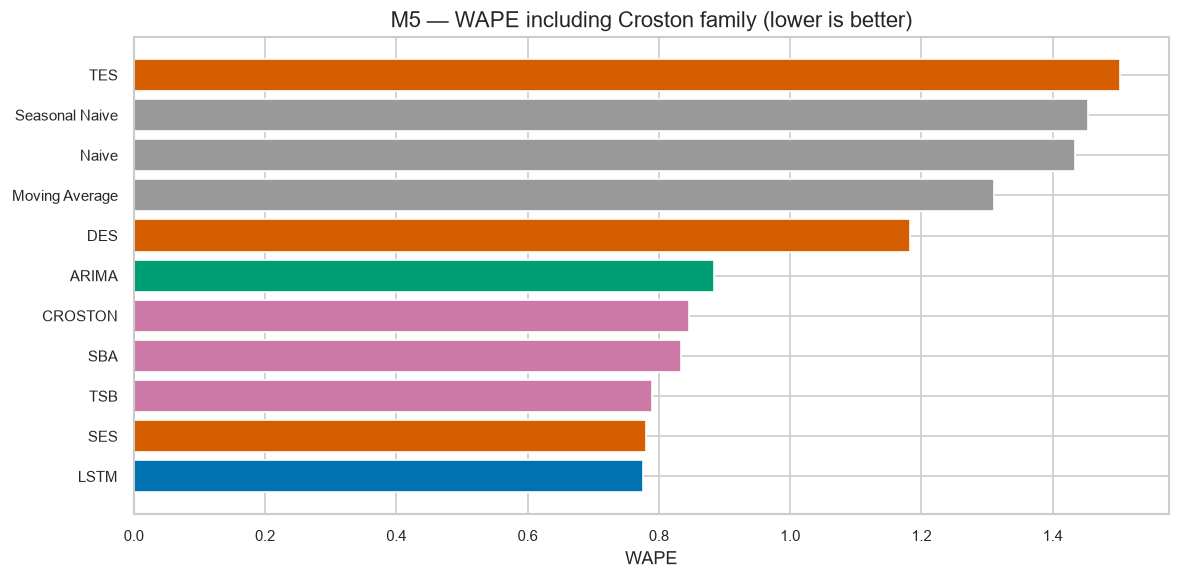

Saved 01_comparison_WAPE_with_croston.png


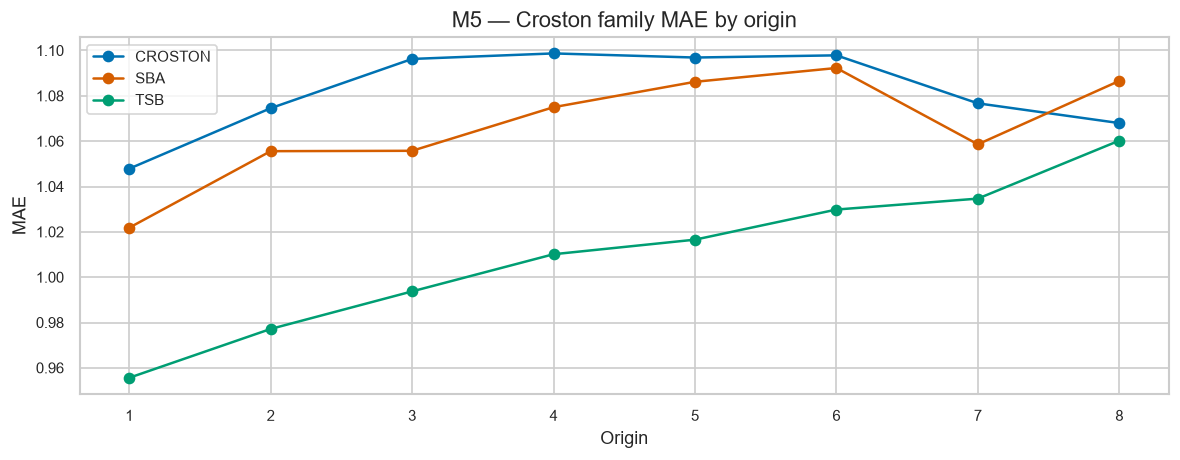

Saved 02_mae_by_origin.png



CROSTON archetype
          archetype    MAE         WAPE
Highly Intermittent 0.4490 2.195839e+09
       Intermittent 1.1034 7.389382e+09
           Variable 2.0370 2.133973e+10
             Smooth 2.3800 4.410000e-01
           Moderate 2.6550 6.143000e-01

SBA archetype
          archetype    MAE         WAPE
Highly Intermittent 0.4474 2.000939e+09
       Intermittent 1.0720 6.111880e+09
           Variable 2.0002 1.325650e+10
             Smooth 2.5712 4.764000e-01
           Moderate 2.7129 6.195000e-01

TSB archetype
          archetype    MAE         WAPE
Highly Intermittent 0.4299 4.010389e+07
       Intermittent 1.0282 1.137700e+00
           Variable 1.8202 8.469000e-01
             Smooth 2.3800 4.410000e-01
           Moderate 2.6488 6.209000e-01


In [8]:
# Figures
for metric in ["MAE","WAPE"]:
    fig, ax = plt.subplots(figsize=(10,5))
    sub=combined_df.sort_values(metric)
    colors=["#999999" if f=="Baseline" else "#D55E00" if f=="Smoothing" else "#0072B2" if f=="LSTM" else "#009E73" if f=="ARIMA/SARIMA" else "#CC79A7" for f in sub["family"]]
    ax.barh(sub["model"], sub[metric], color=colors, edgecolor="white")
    ax.set_title(f"M5 — {metric} including Croston family (lower is better)")
    ax.set_xlabel(metric)
    plt.tight_layout()
    plt.savefig(FIG_EXP / f"01_comparison_{metric}_with_croston.png", bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved 01_comparison_{metric}_with_croston.png")

# Per-origin stability for Croston/SBA/TSB vs SES/MA
fig, ax = plt.subplots(figsize=(10,4))
for model, color in [("CROSTON","#0072B2"),("SBA","#D55E00"),("TSB","#009E73")]:
    sub=per_origin[(per_origin["model"]==model)]
    ax.plot(sub["origin"], sub["MAE"], marker="o", label=model, color=color)
ax.set_title("M5 — Croston family MAE by origin")
ax.set_xlabel("Origin"); ax.set_ylabel("MAE"); ax.legend()
plt.tight_layout()
plt.savefig(FIG_EXP / "02_mae_by_origin.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved 02_mae_by_origin.png")

# Archetype
prof=pd.read_csv(PROJ / "02_data/dataset_01_m5/processed/m5_series_profile.csv")
prof["id_eval"]=prof["item_id"].astype(str)+"_"+prof["store_id"].astype(str)+"_evaluation"
for model in ["CROSTON","SBA","TSB"]:
    sub=per_series[(per_series["model"]==model)].merge(prof[["id_eval","archetype"]], left_on="series_id", right_on="id_eval", how="left")
    arch=sub.groupby("archetype")[["MAE","WAPE"]].mean().reset_index().sort_values("MAE")
    print(f"\n{model} archetype")
    print(arch.round(4).to_string(index=False))
    arch.to_csv(RES / f"metrics_by_archetype_m5_{model.lower()}.csv", index=False)

---

# 9. Limitations & Inventory Implications

- Flat forecast cannot capture weekly seasonality; archetype Smooth (trend/seasonal) likely favors SES/MA over Croston. Intermittent/Highly Intermittent should favor SBA/TSB.
- Bias correction (SBA 0.95) lowers holding but may raise stockout slightly; evaluated in §11 sensitivity.
- TSB should dominate where items go obsolete (long zeros tail); else similar to SBA.
- No Store Item evaluation — dense demand violates intermittency (p̂≈1, forecast ≈ SES size). If forced, would duplicate MA without benefit; kept as negative finding with justification.

In [9]:
figs_edu=sorted((PROJ / "07_figures/model_explanations/croston").glob("*.png"))
figs_exp=sorted((PROJ / "07_figures/croston").glob("*.png"))
print(f"Educational {len(figs_edu)}: {[p.name for p in figs_edu]}")
print(f"Experimental {len(figs_exp)}: {[p.name for p in figs_exp]}")
print(f"Results: {sorted(p.name for p in RES.glob('*'))}")
print("No frozen design change except addition of intermittent specialist; same window/origins/seed")

Educational 2: ['01_croston_intuition.png', '02_croston_sba_tsb.png']
Experimental 3: ['01_comparison_MAE_with_croston.png', '01_comparison_WAPE_with_croston.png', '02_mae_by_origin.png']
Results: ['all_forecasts.csv', 'all_forecasts_croston.csv', 'all_forecasts_sba.csv', 'all_forecasts_tsb.csv', 'metrics_by_archetype_m5_croston.csv', 'metrics_by_archetype_m5_sba.csv', 'metrics_by_archetype_m5_tsb.csv', 'metrics_by_model.csv', 'metrics_by_origin.csv', 'metrics_by_series.csv', 'metrics_with_history.csv', 'validation_selection.json']
No frozen design change except addition of intermittent specialist; same window/origins/seed
